In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Thu Sep 24 11:13:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -U transformers datasets peft trl bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 38.1 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
  Attemptin

In [ ]:
import torch
from datasets import load_dataset
from transformers import (
AutoTokenizer,
AutoModelForCausalLM,
BitsAndBytesConfig
)
from peft import LoraConfig

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
!pip install -U datasets

In [ ]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [ ]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(500))

In [ ]:
print("Training:", len(train_dataset))
print("Testing:", len(test_dataset))

Training: 2000
Testing: 500


In [ ]:
def format_example(example):
  sentiment = "Positive" if example["label"] == 1 else "Negative"
  return {
    "text": f"""Review:
{example["text"]}
Sentiment:
{sentiment}"""
}

In [ ]:
train_dataset = train_dataset.map(format_example)
test_dataset = test_dataset.map(format_example)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0]["text"])

Review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it's the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...
Sentiment:
Positive


In [ ]:
!pip install -U transformers peft trl bitsandbytes accelerate

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
bnb_config = BitsAndBytesConfig(
load_in_4bit=True,
bnb_4bit_quant_type="nf4",
bnb_4bit_compute_dtype=torch.float16,
bnb_4bit_use_double_quant=True
)

In [ ]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
model_name,
quantization_config=bnb_config,
device_map="auto"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
print("Tokenizer loaded successfully!")
print("Pad token:", tokenizer.pad_token)

Tokenizer loaded successfully!
Pad token: <|im_end|>


In [ ]:
from peft import prepare_model_for_kbit_training
model = prepare_model_for_kbit_training(model)
print("Model prepared for QLoRA training!")

Model prepared for QLoRA training!


In [ ]:
from peft import LoraConfig
lora_config = LoraConfig(
r=16,
lora_alpha=32,
lora_dropout=0.05,
bias="none",
task_type="CAUSAL_LM",
target_modules=[
"q_proj",
"k_proj",
"v_proj",
"o_proj"
]
)
print("LoRA configuration created!")

LoRA configuration created!


In [ ]:
import trl
print("TRL version:", trl.__version__)

TRL version: 1.13.0


In [ ]:
from trl import SFTConfig
training_args = SFTConfig(
output_dir="./qwen_imdb_qlora",
num_train_epochs=1,
per_device_train_batch_size=2,
gradient_accumulation_steps=4,
learning_rate=2e-4,
logging_steps=10,
save_steps=100,
fp16=True,
report_to="none",
max_length=512
)
print("Training configuration created!")

Training configuration created!


In [ ]:
from trl import SFTTrainer
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("SFT Trainer created successfully!")

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

SFT Trainer created successfully!


In [ ]:
import torch
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("FP16 available:", torch.cuda.is_available())

BF16 supported: True
FP16 available: True


In [ ]:
from trl import SFTConfig
training_args = SFTConfig(
output_dir="./qwen_imdb_qlora",
num_train_epochs=1,
per_device_train_batch_size=2,
gradient_accumulation_steps=4,
learning_rate=2e-4,
logging_steps=10,
save_steps=100,
bf16=True,
fp16=False,
report_to="none",
max_length=512
)
print("Fixed training configuration created!")

Fixed training configuration created!


In [ ]:
from trl import SFTTrainer
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("Trainer recreated successfully!")

/usr/local/lib/python3.13/dist-packages/peft/mapping_func.py:148: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:331: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Trainer recreated successfully!


In [ ]:
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained(
model_name,
quantization_config=bnb_config,
device_map="auto"
)
model = prepare_model_for_kbit_training(model)
print("Clean Qwen model loaded and prepared!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Clean Qwen model loaded and prepared!


In [ ]:
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("Clean trainer created successfully!")

Clean trainer created successfully!


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
10,3.208742
20,3.078950
30,3.001978
40,3.007062
50,2.960383
60,2.938168
70,3.009289
80,2.955484
90,3.015396
100,3.003967


TrainOutput(global_step=250, training_loss=2.9884149017333983, metrics={'train_runtime': 3269.7393, 'train_samples_per_second': 0.612, 'train_steps_per_second': 0.076, 'total_flos': 5377649033975808.0, 'train_loss': 2.9884149017333983, 'epoch': 1.0})

In [62]:
adapter_path = "./qwen_imdb_qlora"

trainer.save_model(adapter_path)

print("QLoRA adapter saved successfully!")

QLoRA adapter saved successfully!


In [63]:
import os

print(os.listdir(adapter_path))

['checkpoint-250', 'training_args.bin', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'tokenizer_config.json', 'checkpoint-100', 'tokenizer.json', 'checkpoint-200', 'chat_template.jinja']


In [64]:
test_review = """
This movie was absolutely fantastic. The story was engaging,
the actors gave excellent performances, and I really enjoyed
every minute of it.
"""

prompt = f"""Review:
{test_review}

Sentiment:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(response)

Review:

This movie was absolutely fantastic. The story was engaging,
the actors gave excellent performances, and I really enjoyed
every minute of it.


Sentiment:
Positive


In [65]:
test_review = """
This movie was terrible. The story was boring and predictable,
the acting was poor, and I regretted watching it.
"""

prompt = f"""Review:
{test_review}

Sentiment:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=5
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(response)

Review:

This movie was terrible. The story was boring and predictable,
the acting was poor, and I regretted watching it.


Sentiment:
Negative


In [66]:
correct = 0
total = 20

for i in range(total):
    review = test_dataset[i]["text"]

    # Get the original sentiment
    actual = "Positive" if test_dataset[i]["label"] == 1 else "Negative"

    # Extract only the review from our formatted text
    review_text = review.split("Sentiment:")[0].replace("Review:", "").strip()

    prompt = f"""Review:
{review_text}

Sentiment:"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip().lower()

    if generated.startswith("positive"):
        predicted = "Positive"
    elif generated.startswith("negative"):
        predicted = "Negative"
    else:
        predicted = "Unknown"

    if predicted == actual:
        correct += 1

    print(f"{i+1}. Actual: {actual} | Predicted: {predicted}")

accuracy = correct / total * 100

print("\n" + "=" * 40)
print(f"Correct: {correct}/{total}")
print(f"Accuracy: {accuracy:.2f}%")
print("=" * 40)

1. Actual: Positive | Predicted: Positive
2. Actual: Positive | Predicted: Positive
3. Actual: Negative | Predicted: Negative
4. Actual: Positive | Predicted: Positive
5. Actual: Negative | Predicted: Negative
6. Actual: Positive | Predicted: Positive
7. Actual: Positive | Predicted: Negative
8. Actual: Negative | Predicted: Negative
9. Actual: Negative | Predicted: Negative
10. Actual: Positive | Predicted: Positive
11. Actual: Positive | Predicted: Positive
12. Actual: Negative | Predicted: Negative
13. Actual: Negative | Predicted: Negative
14. Actual: Negative | Predicted: Negative
15. Actual: Positive | Predicted: Positive
16. Actual: Positive | Predicted: Positive
17. Actual: Negative | Predicted: Negative
18. Actual: Negative | Predicted: Negative
19. Actual: Positive | Predicted: Positive
20. Actual: Positive | Predicted: Positive

Correct: 19/20
Accuracy: 95.00%


In [67]:
correct = 0
unknown = 0
predictions = []

model.eval()

for i, example in enumerate(test_dataset):

    # Extract original review
    review_text = example["text"].split("Sentiment:")[0]
    review_text = review_text.replace("Review:", "").strip()

    actual = example["label"]

    prompt = f"""Review:
{review_text}

Sentiment:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip().lower()

    if "positive" in generated:
        predicted = 1
    elif "negative" in generated:
        predicted = 0
    else:
        predicted = None
        unknown += 1

    predictions.append(predicted)

    if predicted == actual:
        correct += 1

    if (i + 1) % 50 == 0:
        print(f"Processed: {i + 1}/500")

accuracy = correct / len(test_dataset) * 100

print("\n" + "=" * 50)
print("FINAL EVALUATION")
print("=" * 50)
print(f"Total Reviews : {len(test_dataset)}")
print(f"Correct       : {correct}")
print(f"Unknown       : {unknown}")
print(f"Accuracy      : {accuracy:.2f}%")
print("=" * 50)

Processed: 50/500
Processed: 100/500
Processed: 150/500
Processed: 200/500
Processed: 250/500
Processed: 300/500
Processed: 350/500
Processed: 400/500
Processed: 450/500
Processed: 500/500

FINAL EVALUATION
Total Reviews : 500
Correct       : 466
Unknown       : 0
Accuracy      : 93.20%


Confusion Matrix:
[[245   9]
 [ 25 221]]


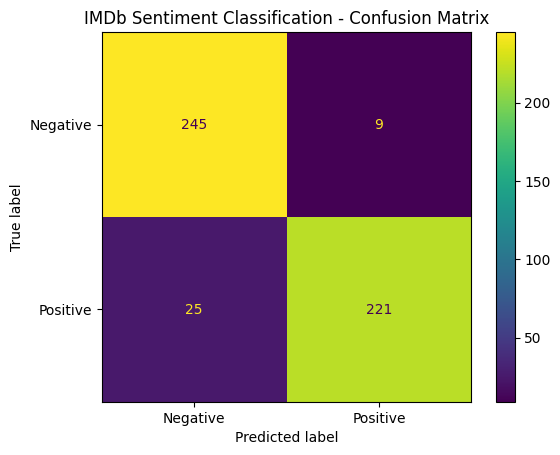

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Remove any unknown predictions
valid_indices = [
    i for i, pred in enumerate(predictions)
    if pred is not None
]

actual_labels = [
    test_dataset[i]["label"]
    for i in valid_indices
]

predicted_labels = [
    predictions[i]
    for i in valid_indices
]

# Create confusion matrix
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("IMDb Sentiment Classification - Confusion Matrix")
plt.show()

In [69]:
from sklearn.metrics import classification_report

print(classification_report(
    actual_labels,
    predicted_labels,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.96      0.94       254
    Positive       0.96      0.90      0.93       246

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



In [70]:
# ============================================================
# IMDb SENTIMENT ANALYZER - GRADIO FRONTEND
# Qwen2.5-1.5B + QLoRA
# ============================================================

!pip install -q gradio

import torch
import gradio as gr

# ------------------------------------------------------------
# Make sure the trained model is ready
# ------------------------------------------------------------

model.eval()

# Disable cache warning during generation
model.config.use_cache = True

print("Model ready for inference!")


# ------------------------------------------------------------
# Sentiment Prediction Function
# ------------------------------------------------------------

def predict_sentiment(review):

    if review is None or not review.strip():
        return (
            "⚠️ Please enter a movie review.",
            "No prediction",
            ""
        )

    review = review.strip()

    # Prompt format used during QLoRA training
    prompt = f"""Review:
{review}
Sentiment:"""

    # Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Move inputs to model device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Generate sentiment
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    # Extract only newly generated tokens
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    generated = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    generated_lower = generated.lower()

    # --------------------------------------------------------
    # Detect sentiment
    # --------------------------------------------------------

    if "positive" in generated_lower:
        sentiment = "Positive"
        emoji = "🟢"
        message = "The model classified this review as POSITIVE."

    elif "negative" in generated_lower:
        sentiment = "Negative"
        emoji = "🔴"
        message = "The model classified this review as NEGATIVE."

    else:
        sentiment = "Unknown"
        emoji = "⚪"
        message = "The model could not determine the sentiment."

    # --------------------------------------------------------
    # Result display
    # --------------------------------------------------------

    result = f"""
{emoji} **{sentiment}**

{message}
"""

    raw_output = f"Model output: `{generated}`"

    return result, sentiment, raw_output


# ------------------------------------------------------------
# Clear function
# ------------------------------------------------------------

def clear_all():
    return "", "", ""


# ============================================================
# CUSTOM CSS
# ============================================================

custom_css = """

/* Main background */
.gradio-container {
    background:
        radial-gradient(circle at top left, #172554 0%, transparent 35%),
        radial-gradient(circle at bottom right, #312e81 0%, transparent 35%),
        #020617 !important;

    color: white !important;
}

/* Main title */
.main-title {
    text-align: center;
    font-size: 38px;
    font-weight: 800;
    margin-bottom: 5px;
    color: #ffffff;
}

/* Subtitle */
.subtitle {
    text-align: center;
    font-size: 17px;
    color: #cbd5e1;
    margin-bottom: 25px;
}

/* Cards */
.card {
    background: rgba(15, 23, 42, 0.88);
    border: 1px solid rgba(148, 163, 184, 0.20);
    border-radius: 18px;
    padding: 20px;
}

/* Analyze button */
.analyze-btn {
    background: linear-gradient(
        90deg,
        #2563eb,
        #7c3aed
    ) !important;

    color: white !important;
    border: none !important;
    font-size: 18px !important;
    font-weight: 700 !important;
}

/* Clear button */
.clear-btn {
    background: #1e293b !important;
    color: white !important;
}

/* Result box */
.result-box {
    border-radius: 15px;
    font-size: 20px;
    text-align: center;
}

/* Footer */
.footer {
    text-align: center;
    color: #94a3b8;
    font-size: 13px;
    margin-top: 25px;
}

"""


# ============================================================
# GRADIO FRONTEND
# ============================================================

with gr.Blocks(
    title="IMDb Sentiment Analyzer",
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="purple",
        neutral_hue="slate"
    ),
    css=custom_css
) as demo:

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    gr.HTML("""
    <div class="main-title">
        🎬 IMDb Sentiment Analyzer
    </div>

    <div class="subtitle">
        Qwen2.5-1.5B • QLoRA Fine-Tuning • IMDb Dataset
    </div>
    """)

    # --------------------------------------------------------
    # Information
    # --------------------------------------------------------

    gr.Markdown("""
    ### 🤖 AI-Powered Movie Review Analysis

    Enter a movie review below and the fine-tuned **Qwen2.5-1.5B**
    model will classify it as **Positive** or **Negative**.
    """)

    with gr.Row():

        # ----------------------------------------------------
        # LEFT SIDE - INPUT
        # ----------------------------------------------------

        with gr.Column(scale=1, elem_classes="card"):

            gr.Markdown("### 📝 Enter Movie Review")

            review_input = gr.Textbox(
                label="Movie Review",
                placeholder=(
                    "Example: This movie was fantastic! "
                    "The acting and story were excellent..."
                ),
                lines=10,
                max_lines=15
            )

            with gr.Row():

                analyze_button = gr.Button(
                    "🔍 Analyze Sentiment",
                    variant="primary",
                    elem_classes="analyze-btn"
                )

                clear_button = gr.Button(
                    "🧹 Clear",
                    elem_classes="clear-btn"
                )

            gr.Markdown("### 💡 Try an Example")

            gr.Examples(
                examples=[
                    [
                        "This movie was absolutely fantastic. "
                        "The story was engaging and the actors "
                        "gave excellent performances."
                    ],
                    [
                        "This movie was terrible. "
                        "The story was boring, predictable, "
                        "and the acting was very poor."
                    ],
                    [
                        "I really enjoyed this film. "
                        "The characters were interesting and "
                        "the ending was excellent."
                    ],
                    [
                        "One of the worst movies I have ever watched. "
                        "It was slow, boring and completely disappointing."
                    ]
                ],
                inputs=review_input
            )

        # ----------------------------------------------------
        # RIGHT SIDE - OUTPUT
        # ----------------------------------------------------

        with gr.Column(scale=1, elem_classes="card"):

            gr.Markdown("### 📊 Sentiment Result")

            result_output = gr.Markdown(
                value="### 👋 Enter a review to get started.",
                elem_classes="result-box"
            )

            sentiment_output = gr.Textbox(
                label="Prediction",
                interactive=False
            )

            raw_output = gr.Textbox(
                label="Model Generated Output",
                interactive=False
            )

            gr.Markdown("""
            ### 🧠 Model Information

            **Base Model:** Qwen2.5-1.5B-Instruct
            **Fine-Tuning:** QLoRA
            **Quantization:** 4-bit NF4
            **Dataset:** IMDb
            **Task:** Binary Sentiment Classification
            """)

    # --------------------------------------------------------
    # Button actions
    # --------------------------------------------------------

    analyze_button.click(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=[
            result_output,
            sentiment_output,
            raw_output
        ]
    )

    clear_button.click(
        fn=clear_all,
        inputs=[],
        outputs=[
            review_input,
            sentiment_output,
            raw_output
        ]
    )

    # Also allow Enter-style submission
    review_input.submit(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=[
            result_output,
            sentiment_output,
            raw_output
        ]
    )

    # --------------------------------------------------------
    # Footer
    # --------------------------------------------------------

    gr.HTML("""
    <div class="footer">
        Built with Qwen2.5-1.5B + QLoRA + Hugging Face + Gradio
        <br>
        Fine-tuned on IMDb movie reviews
    </div>
    """)


# ============================================================
# LAUNCH
# ============================================================

print("🚀 Launching IMDb Sentiment Analyzer...")

demo.launch(
    share=True,
    debug=False
)

Model ready for inference!


/tmp/ipykernel_1731/636952413.py:198: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


🚀 Launching IMDb Sentiment Analyzer...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://00bb773caea8856c73.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
